<h3><b> Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

<h3><b>Load the data

In [2]:
# Change this path to wherever clients.csv actually sits on your machine
c = pd.read_csv('clients.csv')

c.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


<h3><b>Define the DOB parsing function

In [3]:
# Two formats exist in date_of_birth:
# - Dash format (e.g. 05-11-1968) -> treated as DD-MM-YYYY
# - Slash format (e.g. 11/26/1962) -> forced to be MM-DD-YYYY,
#   because every slash row has a second number > 12, which is
#   impossible as a month, so DD-MM can't apply to these rows.

def parse_dob(s):
    if '/' in s:
        dt = datetime.strptime(s, '%m/%d/%Y')  # slash rows = MM/DD/YYYY
    else:
        dt = datetime.strptime(s, '%d-%m-%Y')  # dash rows = DD-MM-YYYY
    return dt

<h3><b>Apply the parser and standardize output format

In [4]:
c['dob_parsed'] = c['date_of_birth'].apply(parse_dob)

# Standardize every row to one consistent output format: DD-MM-YYYY
c['dob_clean'] = c['dob_parsed'].dt.strftime('%d-%m-%Y')

c[['client_id', 'date_of_birth', 'dob_clean']].head(10)

,client_id,date_of_birth,dob_clean
0,C0001,05-11-1968,05-11-1968
1,C0002,11/26/1962,26-11-1962
2,C0003,04-07-1959,04-07-1959
3,C0004,11/25/1959,25-11-1959
4,C0005,2/28/1976,28-02-1976
5,C0006,03-06-1957,03-06-1957
6,C0007,5/24/1947,24-05-1947
7,C0008,10/17/1969,17-10-1969
8,C0009,10-05-1975,10-05-1975
9,C0010,6/17/1966,17-06-1966


<h3><b>Derive age

In [5]:
# Reference date is Dec 31, 2025, not today's real date --
# this is a synthetic dataset and the transaction data runs through late 2025,
# so using the actual current date would produce meaningless ages.
today_ref = datetime(2025, 12, 31)

c['age'] = c['dob_parsed'].apply(
    lambda d: today_ref.year - d.year - ((today_ref.month, today_ref.day) < (d.month, d.day))
)

c['age'].describe()

count    2000.000000
mean       55.099000
std        17.343719
min        25.000000
25%        40.000000
50%        56.000000
75%        70.000000
max        94.000000
Name: age, dtype: float64

<h3><b>Sanity checks

In [6]:
# Confirm no broken/impossible ages came out of parsing
print("Negative ages:", (c['age'] < 0).sum())
print("Ages over 100:", (c['age'] > 100).sum())
print()
print("client_type values:", c['client_type'].unique())

Negative ages: 0
Ages over 100: 0

client_type values: ['Individual' 'Company']


<h3><b>Save the cleaned file

In [7]:
c.to_csv('clients_cleaned.csv', index=False)
print("Saved. Shape:", c.shape)

Saved. Shape: (2000, 15)


<h3><b>Check unique values before encoding (sanity check)

In [8]:
# Quick check of what we're encoding, so nothing unexpected slips in
print("client_type:", c['client_type'].unique())
print("gender:", c['gender'].unique())
print("loan_applied:", c['loan_applied'].unique())
print("acquisition_purpose:", c['acquisition_purpose'].unique())
print("country:", c['country'].unique())
print("referral_channel:", c['referral_channel'].unique())

client_type: ['Individual' 'Company']
gender: ['F' 'M']
loan_applied: ['Yes' 'No']
acquisition_purpose: ['Home' 'Investment']
country: ['USA' 'Canada' 'Germany' 'Belgium' 'Mexico' 'Russia' 'UK' 'Denmark'
 'France' 'Australia']
referral_channel: ['Website' 'Agency' 'Client']


<h3><b>Binary encode the true 2-value fields

In [9]:
# These 4 fields have exactly 2 categories each, so a single 0/1 column
# is correct here - there's no ranking implied when there's only 2 values.

c['client_type_enc'] = c['client_type'].map({'Individual': 0, 'Company': 1})
c['gender_enc'] = c['gender'].map({'F': 0, 'M': 1})
c['loan_applied_enc'] = c['loan_applied'].map({'No': 0, 'Yes': 1})
c['acquisition_purpose_enc'] = c['acquisition_purpose'].map({'Home': 0, 'Investment': 1})

# Sanity check: no NaNs introduced by the mapping (would mean an unexpected category slipped in)
print(c[['client_type_enc','gender_enc','loan_applied_enc','acquisition_purpose_enc']].isnull().sum())

client_type_enc            0
gender_enc                 0
loan_applied_enc           0
acquisition_purpose_enc    0
dtype: int64


<h3><b>One-hot encode country and referral_channel

In [10]:
# country and referral_channel have 3+ categories with no natural order,
# so one-hot is correct here (label encoding would falsely imply ranking).

c_encoded = pd.get_dummies(c, columns=['country', 'referral_channel'], prefix=['country', 'referral'])

# Check the new one-hot columns were added
[col for col in c_encoded.columns if col.startswith('country_') or col.startswith('referral_')]

['country_Australia',
 'country_Belgium',
 'country_Canada',
 'country_Denmark',
 'country_France',
 'country_Germany',
 'country_Mexico',
 'country_Russia',
 'country_UK',
 'country_USA',
 'referral_Agency',
 'referral_Client',
 'referral_Website']

<h3><b>Build the final feature set for clustering

In [11]:
# region is intentionally excluded here - it stays in the original
# dataframe for dashboard filtering later, but doesn't go into the model.

feature_cols = (
    ['client_type_enc', 'gender_enc', 'loan_applied_enc', 'acquisition_purpose_enc', 'age', 'satisfaction_score']
    + [col for col in c_encoded.columns if col.startswith('country_') or col.startswith('referral_')]
)

X = c_encoded[feature_cols].copy()

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (2000, 19)


,client_type_enc,gender_enc,loan_applied_enc,acquisition_purpose_enc,age,satisfaction_score,country_Australia,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,country_UK,country_USA,referral_Agency,referral_Client,referral_Website
0,0,0,1,0,57,4,False,False,False,False,False,False,False,False,False,True,False,False,True
1,0,1,0,0,63,1,False,False,False,False,False,False,False,False,False,True,False,False,True
2,0,1,1,0,66,4,False,False,False,False,False,False,False,False,False,True,True,False,False
3,0,1,0,0,66,5,False,False,False,False,False,False,False,False,False,True,False,False,True
4,1,1,0,1,49,5,False,False,False,False,False,False,False,False,False,True,False,False,True


<h3><b>Scale the numeric features

In [12]:
from sklearn.preprocessing import StandardScaler

# Only age and satisfaction_score need scaling - they're on different
# ranges (age: 25-94, satisfaction_score: 1-5) which would otherwise let
# age dominate distance calculations in K-Means. Binary/one-hot columns
# are already 0/1, no scaling needed for those.

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['age', 'satisfaction_score']] = scaler.fit_transform(X[['age', 'satisfaction_score']])

X_scaled.head()

,client_type_enc,gender_enc,loan_applied_enc,acquisition_purpose_enc,age,satisfaction_score,country_Australia,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,country_UK,country_USA,referral_Agency,referral_Client,referral_Website
0,0,0,1,0,0.109635,0.687089,False,False,False,False,False,False,False,False,False,True,False,False,True
1,0,1,0,0,0.455668,-1.435740,False,False,False,False,False,False,False,False,False,True,False,False,True
2,0,1,1,0,0.628684,0.687089,False,False,False,False,False,False,False,False,False,True,True,False,False
3,0,1,0,0,0.628684,1.394698,False,False,False,False,False,False,False,False,False,True,False,False,True
4,1,1,0,1,-0.351743,1.394698,False,False,False,False,False,False,False,False,False,True,False,False,True


<h3><b>Elbow method + silhouette score across a range of k (K-Means)

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 9)  # can't compute silhouette for k=1, so start at 2

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

for k, inert, sil in zip(k_range, inertia, silhouette_scores):
    print(f"k={k}: inertia={inert:.1f}, silhouette={sil:.4f}")

k=2: inertia=5917.2, silhouette=0.1903
k=3: inertia=4976.3, silhouette=0.1781
k=4: inertia=4439.6, silhouette=0.1616
k=5: inertia=4161.9, silhouette=0.1605
k=6: inertia=3914.4, silhouette=0.1589
k=7: inertia=3762.5, silhouette=0.1550
k=8: inertia=3640.0, silhouette=0.1431


<h3><b>Plot elbow and silhouette to visually confirm the best k

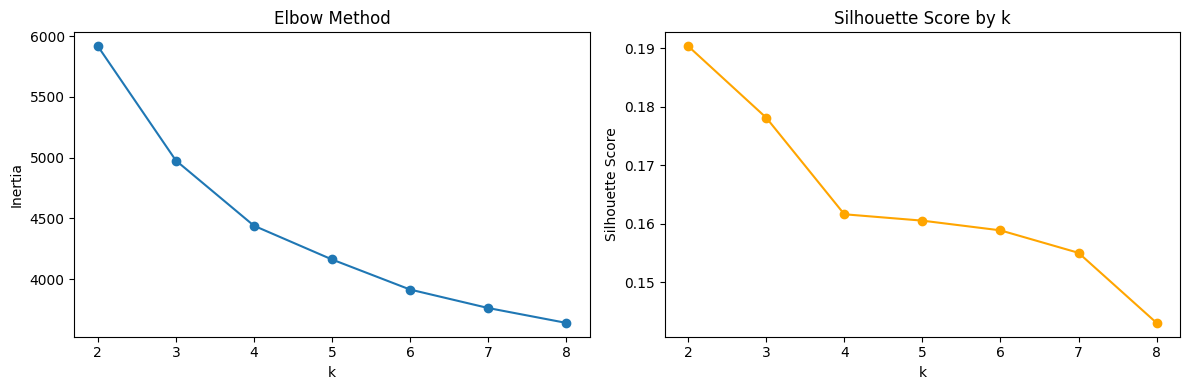

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

<h3><b>Fit K-Means with k=4 and assign cluster labels

In [15]:
# k=4 chosen for interpretability (matches PRD's example segment count),
# not because silhouette showed it was statistically superior to other k values.
# Silhouette scores across k=2-8 ranged 0.14-0.19, below the 0.25 threshold
# usually associated with strong cluster separation - this is stated here
# and should be stated in the paper too, not hidden.

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
c['segment'] = kmeans_final.fit_predict(X_scaled)

c['segment'].value_counts().sort_index()

segment
0    582
1    391
2    423
3    604
Name: count, dtype: int64

<h3><b>Hierarchical clustering as a cross-check

In [16]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=4)
hier_labels = hier.fit_predict(X_scaled)

# Compare agreement between K-Means and Hierarchical using Adjusted Rand Index
# (measures how similarly two clusterings group the same points, 1.0 = identical, 0 = random)
from sklearn.metrics import adjusted_rand_score
agreement = adjusted_rand_score(c['segment'], hier_labels)
print(f"Agreement between K-Means and Hierarchical (Adjusted Rand Index): {agreement:.4f}")

Agreement between K-Means and Hierarchical (Adjusted Rand Index): 0.3573


<h3><b>Profile each segment (what actually distinguishes them)

In [17]:
# This is the real content of your "segmentation" - what does each cluster
# actually look like on the original (non-scaled, non-encoded) fields?

profile_cols = ['client_type', 'gender', 'country', 'acquisition_purpose',
                 'loan_applied', 'referral_channel', 'age', 'satisfaction_score']

for seg in sorted(c['segment'].unique()):
    print(f"\n=== Segment {seg} (n={sum(c['segment']==seg)}) ===")
    sub = c[c['segment'] == seg]
    print("Age: mean =", round(sub['age'].mean(),1))
    print("Satisfaction: mean =", round(sub['satisfaction_score'].mean(),2))
    print("Client type:", sub['client_type'].value_counts(normalize=True).round(2).to_dict())
    print("Acquisition purpose:", sub['acquisition_purpose'].value_counts(normalize=True).round(2).to_dict())
    print("Loan applied:", sub['loan_applied'].value_counts(normalize=True).round(2).to_dict())
    print("Top countries:", sub['country'].value_counts(normalize=True).round(2).head(3).to_dict())


=== Segment 0 (n=582) ===
Age: mean = 39.7
Satisfaction: mean = 4.02
Client type: {'Individual': 0.92, 'Company': 0.08}
Acquisition purpose: {'Home': 0.66, 'Investment': 0.34}
Loan applied: {'No': 0.6, 'Yes': 0.4}
Top countries: {'USA': 0.75, 'UK': 0.05, 'Canada': 0.05}

=== Segment 1 (n=391) ===
Age: mean = 40.2
Satisfaction: mean = 1.44
Client type: {'Individual': 0.92, 'Company': 0.08}
Acquisition purpose: {'Home': 0.66, 'Investment': 0.34}
Loan applied: {'No': 0.63, 'Yes': 0.37}
Top countries: {'USA': 0.78, 'UK': 0.05, 'Belgium': 0.03}

=== Segment 2 (n=423) ===
Age: mean = 69.5
Satisfaction: mean = 4.5
Client type: {'Individual': 0.97, 'Company': 0.03}
Acquisition purpose: {'Home': 0.72, 'Investment': 0.28}
Loan applied: {'No': 0.67, 'Yes': 0.33}
Top countries: {'USA': 0.78, 'UK': 0.04, 'Canada': 0.04}

=== Segment 3 (n=604) ===
Age: mean = 69.5
Satisfaction: mean = 2.07
Client type: {'Individual': 0.98, 'Company': 0.02}
Acquisition purpose: {'Home': 0.72, 'Investment': 0.28}
Loa

<h3><b>Save segmented client data

In [18]:
c.to_csv('clients_segmented.csv', index=False)
print("Saved. Shape:", c.shape)

Saved. Shape: (2000, 20)


<h3><b>Statistical test: does each feature actually differ across segments?

In [19]:
from scipy import stats

# For continuous features (age, satisfaction): ANOVA - tests whether the
# means genuinely differ across the 4 segments, not just look different
print("=== Continuous features (ANOVA) ===")
for col in ['age', 'satisfaction_score']:
    groups = [c[c['segment']==s][col] for s in sorted(c['segment'].unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.2f}, p={p_val:.6f}  {'-> SIGNIFICANT' if p_val < 0.05 else '-> not significant'}")

# For categorical features: Chi-square - tests whether the distribution of
# categories is actually independent of segment, or just looks similar by chance
print("\n=== Categorical features (Chi-square) ===")
for col in ['client_type', 'gender', 'acquisition_purpose', 'loan_applied', 'country', 'referral_channel']:
    contingency = pd.crosstab(c['segment'], c[col])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p={p_val:.6f}  {'-> SIGNIFICANT' if p_val < 0.05 else '-> not significant'}")

=== Continuous features (ANOVA) ===
age: F=1777.15, p=0.000000  -> SIGNIFICANT
satisfaction_score: F=2067.29, p=0.000000  -> SIGNIFICANT

=== Categorical features (Chi-square) ===
client_type: chi2=30.06, p=0.000001  -> SIGNIFICANT
gender: chi2=0.18, p=0.980894  -> not significant
acquisition_purpose: chi2=8.93, p=0.030264  -> SIGNIFICANT
loan_applied: chi2=5.26, p=0.154027  -> not significant
country: chi2=24.90, p=0.580143  -> not significant
referral_channel: chi2=7.98, p=0.239493  -> not significant


<h3><b> Load properties and filter to Sold only

In [20]:
p = pd.read_csv('properties.csv')

# Exclude unsold inventory - confirmed earlier, no buyer means no relevance
# to investment profiling
p_sold = p[p['listing_status'] == 'Sold'].copy()

print("Total properties:", len(p))
print("Sold (kept):", len(p_sold))
print("Available (dropped):", len(p) - len(p_sold))

Total properties: 10000
Sold (kept): 7305
Available (dropped): 2695


<h3><b>Clean sale_price and transaction_date

In [34]:
p_sold['sale_price_clean'] = (
    p_sold['sale_price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# transaction_date is MM-DD-YYYY (day is always 01, month varies 1-12) -
# earlier assumption that format "didn't matter" was wrong; confirmed by
# checking full monthly spread, which only makes sense under MM-DD-YYYY
p_sold['transaction_date_parsed'] = pd.to_datetime(p_sold['transaction_date'], format='%m-%d-%Y')

p_sold[['sale_price', 'sale_price_clean', 'transaction_date', 'transaction_date_parsed']].head()

,sale_price,sale_price_clean,transaction_date,transaction_date_parsed
0,"$300,385.62",300385.62,01-01-2024,2024-01-01
1,"$208,930.81",208930.81,01-01-2024,2024-01-01
2,"$218,585.92",218585.92,01-01-2024,2024-01-01
3,"$246,172.68",246172.68,01-01-2024,2024-01-01
4,"$212,265.67",212265.67,01-01-2024,2024-01-01


<h3><b>Aggregate to one row per buying client

In [22]:
# Per-client aggregation, decided earlier - this is what lets us overlay
# investment behavior onto the Phase 1 client-level segments

client_agg = p_sold.groupby('client_ref').agg(
    num_purchases=('listing_id', 'count'),
    total_spend=('sale_price_clean', 'sum'),
    avg_floor_area=('floor_area_sqft', 'mean'),
).reset_index()

# dominant_property_type: majority category per client (only Apartment/Office exist)
dominant_type = (
    p_sold.groupby('client_ref')['unit_category']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={'unit_category': 'dominant_property_type'})
)

client_agg = client_agg.merge(dominant_type, on='client_ref')

print("Unique buying clients:", len(client_agg))
print("Out of total clients:", len(c))
client_agg.head()

Unique buying clients: 2000
Out of total clients: 2000


,client_ref,num_purchases,total_spend,avg_floor_area,dominant_property_type
0,C0001,4,1246764.72,983.885000,Apartment
1,C0002,5,1841095.93,1187.942000,Apartment
2,C0003,5,1661457.59,1058.110000,Apartment
3,C0004,6,1608263.51,937.103333,Apartment
4,C0005,13,3653385.38,927.296154,Apartment


<h3><b>Merge investment data onto the segmented client table

In [23]:
# left join on client_id - clients who never bought will have NaN in the
# investment columns, which is expected and correct (they're not buyers)
overlay = c.merge(client_agg, left_on='client_id', right_on='client_ref', how='left')

print("Clients with purchase data:", overlay['num_purchases'].notna().sum())
print("Clients with no purchases:", overlay['num_purchases'].isna().sum())
overlay.head()

Clients with purchase data: 2000
Clients with no purchases: 0


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,client_type_enc,gender_enc,loan_applied_enc,acquisition_purpose_enc,segment,client_ref,num_purchases,total_spend,avg_floor_area,dominant_property_type
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,0,0,1,0,2,C0001,4,1246764.72,983.885000,Apartment
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,0,1,0,0,3,C0002,5,1841095.93,1187.942000,Apartment
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,...,0,1,1,0,2,C0003,5,1661457.59,1058.110000,Apartment
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,...,0,1,0,0,2,C0004,6,1608263.51,937.103333,Apartment
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,...,1,1,0,1,0,C0005,13,3653385.38,927.296154,Apartment


<h3><b>Investment stats by segment

In [24]:
# Cross-tab investment behavior against the 4 Phase 1 segments
# (young/high-sat, young/low-sat, old/high-sat, old/low-sat)

overlay_summary = overlay.groupby('segment').agg(
    n_clients=('client_id', 'count'),
    avg_num_purchases=('num_purchases', 'mean'),
    avg_total_spend=('total_spend', 'mean'),
    avg_floor_area=('avg_floor_area', 'mean'),
).round(2)

overlay_summary

,n_clients,avg_num_purchases,avg_total_spend,avg_floor_area
segment,,,,
0,582,3.60,1248971.96,1154.32
1,391,3.59,1232936.18,1137.06
2,423,3.80,1303834.45,1147.73
3,604,3.64,1258690.82,1147.45


<h3><b> Dominant property type by segment

In [25]:
# What proportion of each segment favors Apartment vs Office
pd.crosstab(overlay['segment'], overlay['dominant_property_type'], normalize='index').round(3)

dominant_property_type,Apartment,Office
segment,,
0,0.942,0.058
1,0.962,0.038
2,0.965,0.035
3,0.942,0.058


<h3><b>Statistical check: does investment behavior actually differ by segment?

In [26]:
from scipy import stats

print("=== Investment features by segment (ANOVA) ===")
for col in ['num_purchases', 'total_spend', 'avg_floor_area']:
    groups = [overlay[overlay['segment']==s][col].dropna() for s in sorted(overlay['segment'].unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.2f}, p={p_val:.6f}  {'-> SIGNIFICANT' if p_val < 0.05 else '-> not significant'}")

contingency = pd.crosstab(overlay['segment'], overlay['dominant_property_type'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\ndominant_property_type: chi2={chi2:.2f}, p={p_val:.6f}  {'-> SIGNIFICANT' if p_val < 0.05 else '-> not significant'}")

=== Investment features by segment (ANOVA) ===
num_purchases: F=5.74, p=0.000661  -> SIGNIFICANT
total_spend: F=3.24, p=0.021416  -> SIGNIFICANT
avg_floor_area: F=0.48, p=0.696274  -> not significant

dominant_property_type: chi2=4.70, p=0.194904  -> not significant


<h3><b>Correlation check: does satisfaction or age actually predict spend?

In [27]:
# Since segments were built ON age/satisfaction, check directly whether
# those two features correlate with investment behavior at all
print(overlay[['age', 'satisfaction_score', 'num_purchases', 'total_spend', 'avg_floor_area']].corr().round(3))

                      age  satisfaction_score  num_purchases  total_spend  \
age                 1.000               0.005          0.083        0.057   
satisfaction_score  0.005               1.000          0.070        0.049   
num_purchases       0.083               0.070          1.000        0.710   
total_spend         0.057               0.049          0.710        1.000   
avg_floor_area     -0.011               0.000         -0.125        0.569   

                    avg_floor_area  
age                         -0.011  
satisfaction_score           0.000  
num_purchases               -0.125  
total_spend                  0.569  
avg_floor_area               1.000  


<h1><b>EDA Starts Here

<h3><b>Univariate distributions (numeric fields)

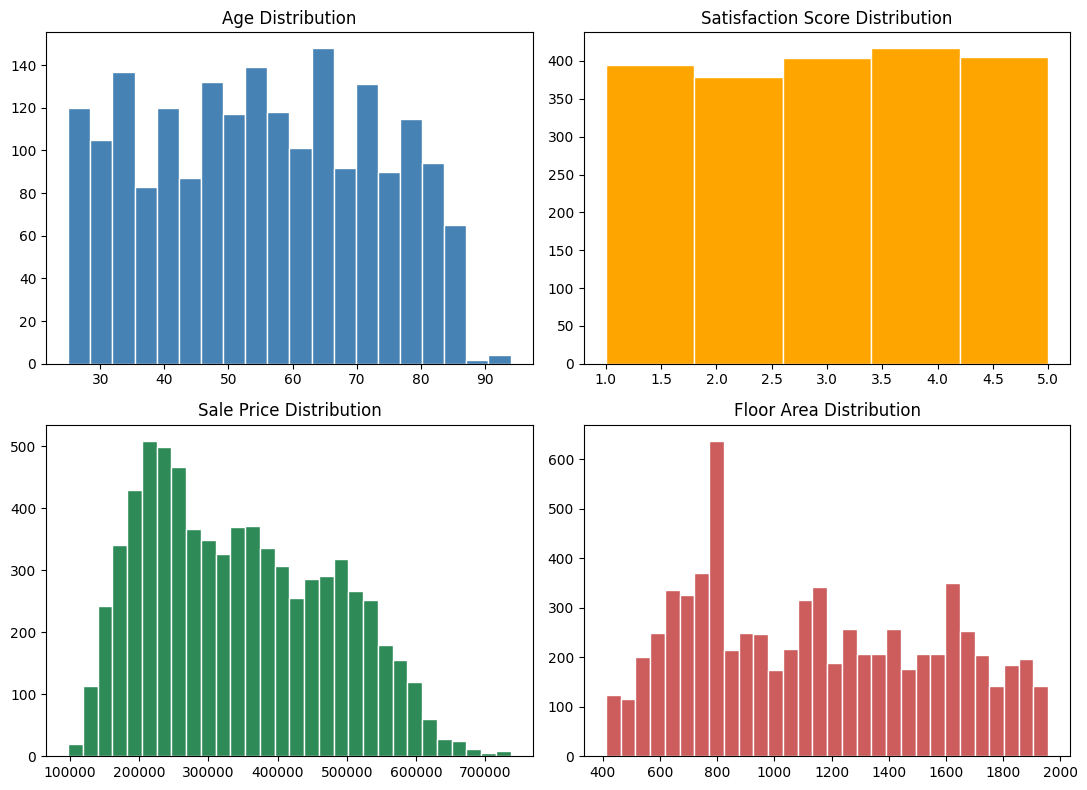

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0,0].hist(c['age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')

axes[0,1].hist(c['satisfaction_score'], bins=5, color='orange', edgecolor='white')
axes[0,1].set_title('Satisfaction Score Distribution')

axes[1,0].hist(p_sold['sale_price_clean'], bins=30, color='seagreen', edgecolor='white')
axes[1,0].set_title('Sale Price Distribution')

axes[1,1].hist(p_sold['floor_area_sqft'], bins=30, color='indianred', edgecolor='white')
axes[1,1].set_title('Floor Area Distribution')

plt.tight_layout()
plt.show()

<h3><b>Outlier check (boxplots)

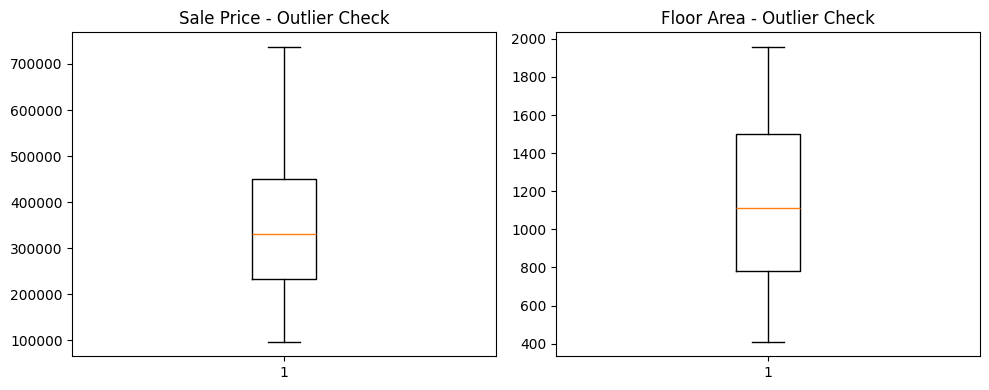

Sale price outliers (IQR method): 0 out of 7305


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(p_sold['sale_price_clean'])
axes[0].set_title('Sale Price - Outlier Check')

axes[1].boxplot(p_sold['floor_area_sqft'])
axes[1].set_title('Floor Area - Outlier Check')

plt.tight_layout()
plt.show()

# Quantify extreme values using IQR method
Q1 = p_sold['sale_price_clean'].quantile(0.25)
Q3 = p_sold['sale_price_clean'].quantile(0.75)
IQR = Q3 - Q1
outliers = p_sold[(p_sold['sale_price_clean'] < Q1 - 1.5*IQR) | (p_sold['sale_price_clean'] > Q3 + 1.5*IQR)]
print(f"Sale price outliers (IQR method): {len(outliers)} out of {len(p_sold)}")

<h3><b> Categorical distributions

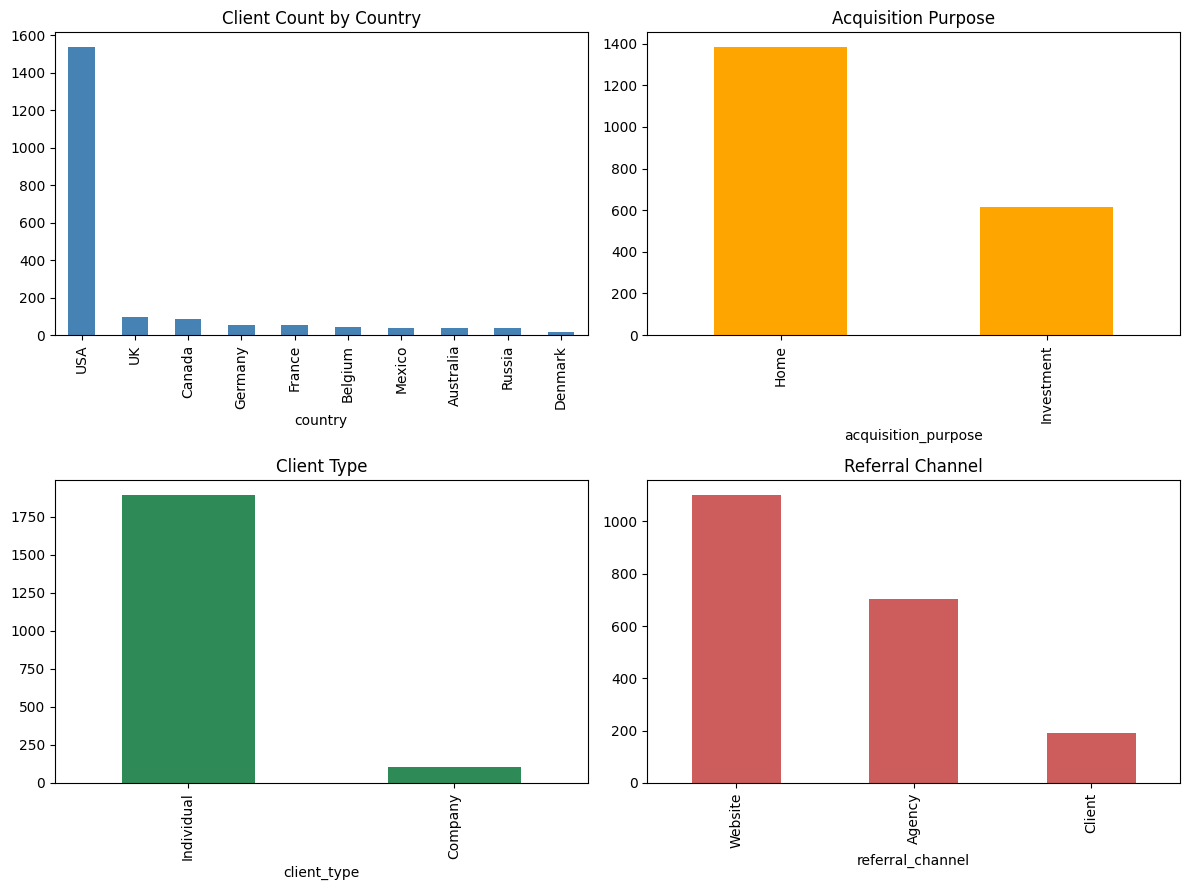

USA share of all clients: 76.9 %


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

c['country'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Client Count by Country')

c['acquisition_purpose'].value_counts().plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('Acquisition Purpose')

c['client_type'].value_counts().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Client Type')

c['referral_channel'].value_counts().plot(kind='bar', ax=axes[1,1], color='indianred')
axes[1,1].set_title('Referral Channel')

plt.tight_layout()
plt.show()

print("USA share of all clients:", round((c['country']=='USA').mean()*100, 1), "%")

<h3><b>Transaction trend over time

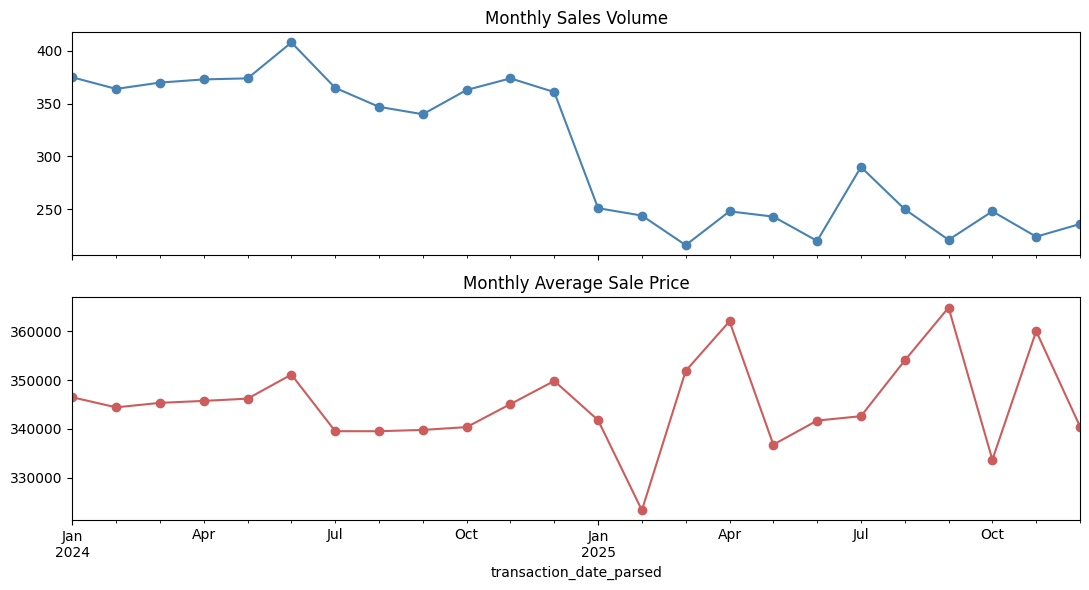

In [36]:
monthly = p_sold.groupby(p_sold['transaction_date_parsed'].dt.to_period('M')).agg(
    num_sales=('listing_id', 'count'),
    avg_price=('sale_price_clean', 'mean')
)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
monthly['num_sales'].plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Monthly Sales Volume')

monthly['avg_price'].plot(ax=axes[1], marker='o', color='indianred')
axes[1].set_title('Monthly Average Sale Price')

plt.tight_layout()
plt.show()

<h3><b> Full correlation heatmap (raw exploratory, before any modeling)

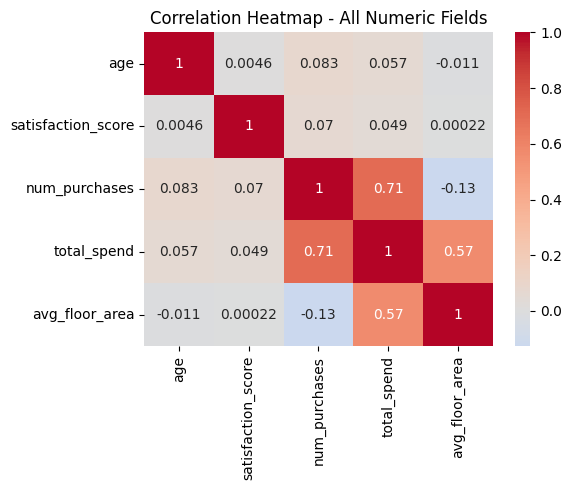

In [32]:
import seaborn as sns

numeric_df = c[['age', 'satisfaction_score']].join(
    overlay[['num_purchases', 'total_spend', 'avg_floor_area']]
)

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - All Numeric Fields')
plt.tight_layout()
plt.show()

<h3><b>Simple bivariate check: satisfaction by acquisition purpose and client type

In [33]:
print("Avg satisfaction by acquisition purpose:")
print(c.groupby('acquisition_purpose')['satisfaction_score'].mean().round(2))
print()
print("Avg satisfaction by client type:")
print(c.groupby('client_type')['satisfaction_score'].mean().round(2))

Avg satisfaction by acquisition purpose:
acquisition_purpose
Home          3.02
Investment    3.04
Name: satisfaction_score, dtype: float64

Avg satisfaction by client type:
client_type
Company       3.07
Individual    3.03
Name: satisfaction_score, dtype: float64
